# **Waste Material Segregation for Improving Waste Management**

## **Objective**

The objective of this project is to implement an effective waste material segregation system using convolutional neural networks (CNNs) that categorises waste into distinct groups. This process enhances recycling efficiency, minimises environmental pollution, and promotes sustainable waste management practices.

The key goals are:

* Accurately classify waste materials into categories like cardboard, glass, paper, and plastic.
* Improve waste segregation efficiency to support recycling and reduce landfill waste.
* Understand the properties of different waste materials to optimise sorting methods for sustainability.

## **Data Understanding**

The Dataset consists of images of some common waste materials.

1. Food Waste
2. Metal
3. Paper
4. Plastic
5. Other
6. Cardboard
7. Glass


**Data Description**

* The dataset consists of multiple folders, each representing a specific class, such as `Cardboard`, `Food_Waste`, and `Metal`.
* Within each folder, there are images of objects that belong to that category.
* However, these items are not further subcategorised. <br> For instance, the `Food_Waste` folder may contain images of items like coffee grounds, teabags, and fruit peels, without explicitly stating that they are actually coffee grounds or teabags.

## **1. Load the data**

Load and unzip the dataset zip file.

**Import Necessary Libraries**

In [ ]:
# Recommended versions:

# numpy version: 1.26.4
# pandas version: 2.2.2
# seaborn version: 0.13.2
# matplotlib version: 3.10.0
# PIL version: 11.1.0
# tensorflow version: 2.18.0
# keras version: 3.8.0
# sklearn version: 1.6.1

In [ ]:
# Import essential libraries
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical


Load the dataset.

In [2]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf




zip_path = "/data.zip"  
extract_path = "/data"


with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset unzipped successfully!")

Dataset unzipped successfully!


## **2. Data Preparation** <font color=red> [25 marks] </font><br>


### **2.1 Load and Preprocess Images** <font color=red> [8 marks] </font><br>

Let us create a function to load the images first. We can then directly use this function while loading images of the different categories to load and crop them in a single step.

#### **2.1.1** <font color=red> [3 marks] </font><br>
Create a function to load the images.

In [3]:
# Create a function to load the raw images

import os
import cv2
import numpy as np

def load_images_from_folder(base_path, img_size=(128, 128)):
    """
    Load all images recursively from folders under base_path.
    Each top-level folder is treated as a class.
    """
    X, y = [], []
    class_names = sorted([d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))])

    for label, class_name in enumerate(class_names):
        class_folder = os.path.join(base_path, class_name)

        for root, _, files in os.walk(class_folder):  # recursively walk through subfolders
            for file in files:
                img_path = os.path.join(root, file)

                # skip non-image files
                if not (file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))):
                    continue

                img = cv2.imread(img_path)
                if img is None:
                    continue  # skip corrupted or unreadable files

                img = cv2.resize(img, img_size)
                img = img / 255.0
                X.append(img)
                y.append(label)

    X = np.array(X, dtype=np.float32)
    y = np.array(y)

    print(f" Loaded {len(X)} images from {len(class_names)} classes.")
    return X, y, class_names



dataset_path = "/data"
X, y, class_names = load_images_from_folder(dataset_path)
print("Classes:", class_names)
print("Image data shape:", X.shape)



 Loaded 7625 images from 1 classes.
Classes: ['data']
Image data shape: (7625, 128, 128, 3)


#### **2.1.2** <font color=red> [5 marks] </font><br>
Load images and labels.

Load the images from the dataset directory. Labels of images are present in the subdirectories.

Verify if the images and labels are loaded correctly.

In [7]:
# Get the images and their labels

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

def load_images_from_folder(base_path, img_size=(128, 128)):
    """
    Loads images and their labels from subdirectories.
    Each subdirectory name is treated as the class label.
    """
    X, y = [], []
    class_names = sorted([d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))])

    for label, class_name in enumerate(class_names):
        class_folder = os.path.join(base_path, class_name)
        for root, _, files in os.walk(class_folder):  # recursive loading
            for file in files:
                if not file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif')):
                    continue

                img_path = os.path.join(root, file)
                img = cv2.imread(img_path)
                if img is None:
                    continue  # skip unreadable files

                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
                img = cv2.resize(img, img_size)
                img = img / 255.0  # Normalize
                X.append(img)
                y.append(label)

    X = np.array(X, dtype=np.float32)
    y = np.array(y)

    print(f" Loaded {len(X)} images from {len(class_names)} classes.")
    print(f"Image shape: {X.shape}")
    print(f"Label shape: {y.shape}")
    print(f"Classes: {class_names}")
    return X, y, class_names



dataset_path = "/data"   
X, y, class_names = load_images_from_folder(dataset_path)

 Loaded 7625 images from 1 classes.
Image shape: (7625, 128, 128, 3)
Label shape: (7625,)
Classes: ['data']


Perform any operations, if needed, on the images and labels to get them into the desired format.

#### **2.2.1** <font color=red> [3 marks] </font><br>
Create a bar plot to display the class distribution

### **2.2 Data Visualisation** <font color=red> [9 marks] </font><br>

Found 7625 total images. Loading...
Loaded 7625 images from 1 classes.
Classes: ['data']
Image data shape: (7625, 128, 128, 3)
Label shape: (7625,)


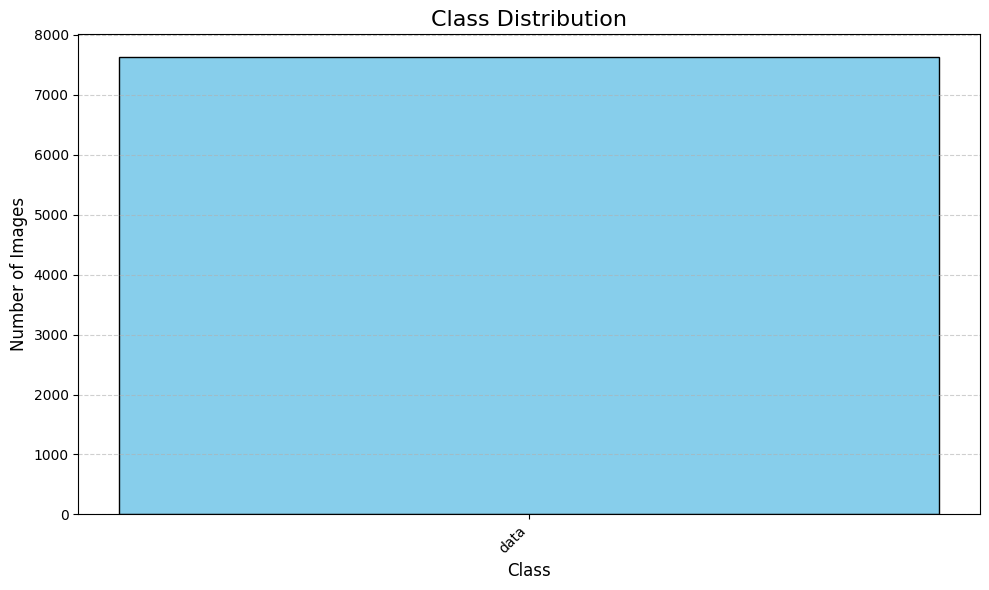

In [4]:
# Visualise Data Distribution
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, as_completed


def load_and_preprocess_image(img_path, img_size, label):
    """Reads and preprocesses a single image safely."""
    try:
        img = cv2.imread(img_path)
        if img is None:
            return None, None
        img = cv2.resize(img, img_size)
        img = img.astype(np.float32) / 255.0
        return img, label
    except Exception:
        return None, None

def load_images_from_folder(base_path, img_size=(128, 128), max_workers=8):
    """
    Load all images (recursively) under base_path using multithreading.
    Each top-level folder is treated as a class.
    """
    X, y = [], []
    class_names = sorted([
        d for d in os.listdir(base_path)
        if os.path.isdir(os.path.join(base_path, d))
    ])

    # Collect all image paths with their labels
    image_tasks = []
    for label, class_name in enumerate(class_names):
        class_folder = os.path.join(base_path, class_name)
        for root, _, files in os.walk(class_folder):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                    img_path = os.path.join(root, file)
                    image_tasks.append((img_path, img_size, label))

    print(f"Found {len(image_tasks)} total images. Loading...")

    # Parallel loading
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [
            executor.submit(load_and_preprocess_image, path, img_size, label)
            for path, img_size, label in image_tasks
        ]
        for future in as_completed(futures):
            img, label = future.result()
            if img is not None:
                X.append(img)
                y.append(label)

    X = np.array(X, dtype=np.float32)
    y = np.array(y)

    print(f"Loaded {len(X)} images from {len(class_names)} classes.")
    return X, y, class_names

def plot_class_distribution(y, class_names):
    """Plot a bar chart showing number of images per class."""
    unique, counts = np.unique(y, return_counts=True)

    plt.figure(figsize=(10, 6))
    plt.bar(class_names, counts, color='skyblue', edgecolor='black')
    plt.title("Class Distribution", fontsize=16)
    plt.xlabel("Class", fontsize=12)
    plt.ylabel("Number of Images", fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    dataset_path = "/data"

    X, y, class_names = load_images_from_folder(
        dataset_path,
        img_size=(128, 128),
        max_workers=8
    )

    print("Classes:", class_names)
    print("Image data shape:", X.shape)
    print("Label shape:", y.shape)

    # Plot class distribution
    plot_class_distribution(y, class_names)



#### **2.2.2** <font color=red> [3 marks] </font><br>
Visualise some sample images

Found 7625 total images. Loading...
 Loaded 7625 images from 1 classes.
Classes: ['data']
Image data shape: (7625, 128, 128, 3)
Label shape: (7625,)


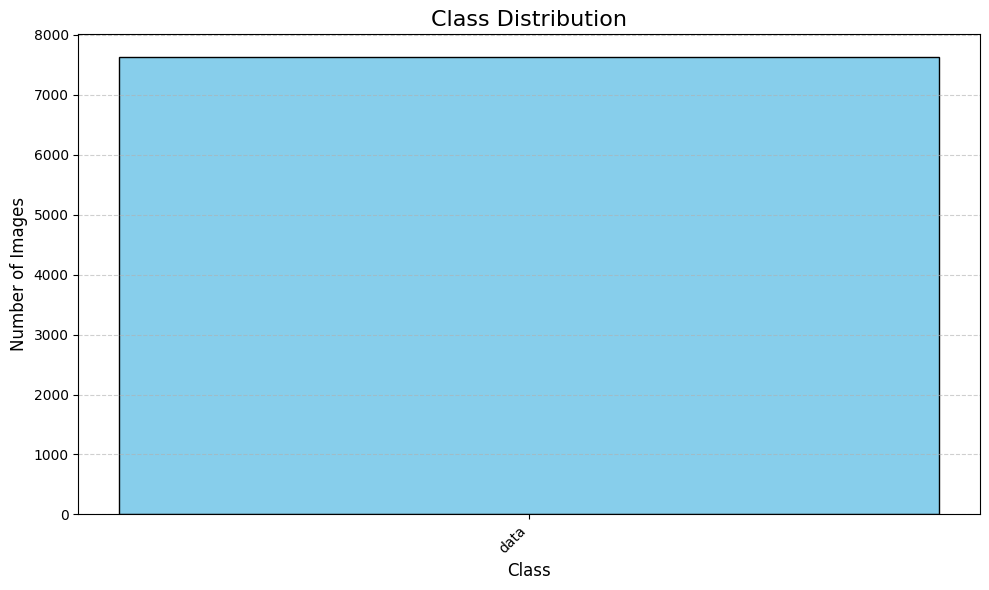

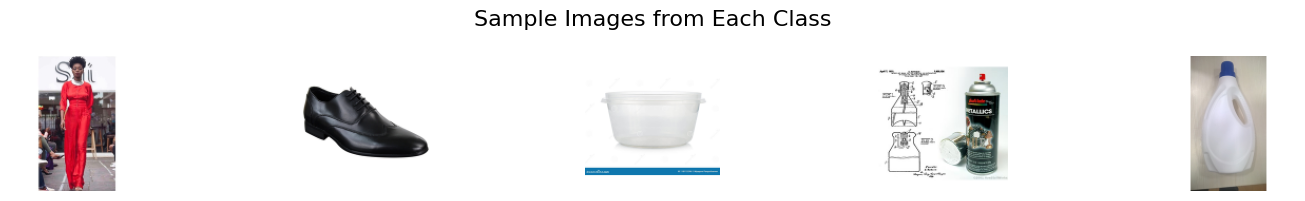

In [5]:
# Visualise Sample Images (across different labels)
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, as_completed


def load_and_preprocess_image(img_path, img_size, label):
    """Reads and preprocesses a single image safely."""
    try:
        img = cv2.imread(img_path)
        if img is None:
            return None, None
        img = cv2.resize(img, img_size)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # convert to RGB for matplotlib
        img = img.astype(np.float32) / 255.0
        return img, label
    except Exception:
        return None, None

def load_images_from_folder(base_path, img_size=(128, 128), max_workers=8):
    """Load all images (recursively) under base_path using multithreading."""
    X, y = [], []
    class_names = sorted([
        d for d in os.listdir(base_path)
        if os.path.isdir(os.path.join(base_path, d))
    ])

    image_tasks = []
    for label, class_name in enumerate(class_names):
        class_folder = os.path.join(base_path, class_name)
        for root, _, files in os.walk(class_folder):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                    img_path = os.path.join(root, file)
                    image_tasks.append((img_path, img_size, label))

    print(f"Found {len(image_tasks)} total images. Loading...")

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [
            executor.submit(load_and_preprocess_image, path, img_size, label)
            for path, img_size, label in image_tasks
        ]
        for future in as_completed(futures):
            img, label = future.result()
            if img is not None:
                X.append(img)
                y.append(label)

    X = np.array(X, dtype=np.float32)
    y = np.array(y)

    print(f" Loaded {len(X)} images from {len(class_names)} classes.")
    return X, y, class_names


def plot_class_distribution(y, class_names):
    """Plot a bar chart showing number of images per class."""
    unique, counts = np.unique(y, return_counts=True)

    plt.figure(figsize=(10, 6))
    plt.bar(class_names, counts, color='skyblue', edgecolor='black')
    plt.title("Class Distribution", fontsize=16)
    plt.xlabel("Class", fontsize=12)
    plt.ylabel("Number of Images", fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


def visualize_sample_images(X, y, class_names, samples_per_class=5):
    """Show a few sample images from each class."""
    plt.figure(figsize=(15, len(class_names) * 2))

    for idx, class_name in enumerate(class_names):
        class_indices = np.where(y == idx)[0]
        chosen_indices = np.random.choice(class_indices, min(samples_per_class, len(class_indices)), replace=False)

        for i, img_idx in enumerate(chosen_indices):
            plt.subplot(len(class_names), samples_per_class, idx * samples_per_class + i + 1)
            plt.imshow(X[img_idx])
            plt.axis('off')
            if i == 0:
                plt.ylabel(class_name, fontsize=12, rotation=0, labelpad=50)

    plt.suptitle("Sample Images from Each Class", fontsize=16)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    dataset_path = "/data"

    X, y, class_names = load_images_from_folder(
        dataset_path,
        img_size=(128, 128),
        max_workers=8
    )

    print("Classes:", class_names)
    print("Image data shape:", X.shape)
    print("Label shape:", y.shape)

    # Plot class distribution
    plot_class_distribution(y, class_names)

    # Visualize sample images
    visualize_sample_images(X, y, class_names, samples_per_class=5)



#### **2.2.3** <font color=red> [3 marks] </font><br>
Based on the smallest and largest image dimensions, resize the images.


 Smallest image: 256x256 pixels (/data\data\Cardboard\file_1.png)
 Largest image:  256x256 pixels (/data\data\Cardboard\file_1.png)

Found 7625 total images. Loading...
 Loaded 7625 images from 1 classes.
Classes: ['data']
Image data shape: (7625, 128, 128, 3)
Label shape: (7625,)


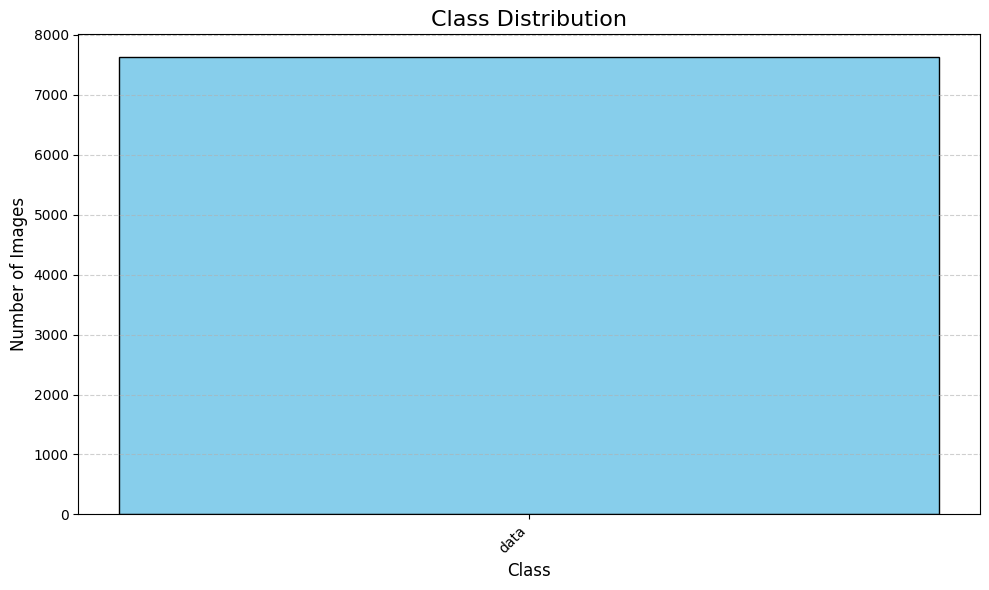

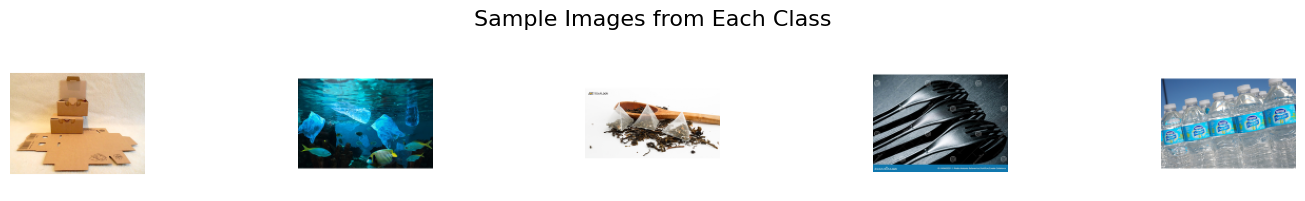

In [6]:
# Find the smallest and largest image dimensions from the data set
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, as_completed


def load_and_preprocess_image(img_path, img_size, label):
    """Reads and preprocesses a single image safely."""
    try:
        img = cv2.imread(img_path)
        if img is None:
            return None, None
        img = cv2.resize(img, img_size)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # convert to RGB for matplotlib
        img = img.astype(np.float32) / 255.0
        return img, label
    except Exception:
        return None, None

def load_images_from_folder(base_path, img_size=(128, 128), max_workers=8):
    """Load all images (recursively) under base_path using multithreading."""
    X, y = [], []
    class_names = sorted([
        d for d in os.listdir(base_path)
        if os.path.isdir(os.path.join(base_path, d))
    ])

    image_tasks = []
    for label, class_name in enumerate(class_names):
        class_folder = os.path.join(base_path, class_name)
        for root, _, files in os.walk(class_folder):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                    img_path = os.path.join(root, file)
                    image_tasks.append((img_path, img_size, label))

    print(f"Found {len(image_tasks)} total images. Loading...")

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [
            executor.submit(load_and_preprocess_image, path, img_size, label)
            for path, img_size, label in image_tasks
        ]
        for future in as_completed(futures):
            img, label = future.result()
            if img is not None:
                X.append(img)
                y.append(label)

    X = np.array(X, dtype=np.float32)
    y = np.array(y)

    print(f" Loaded {len(X)} images from {len(class_names)} classes.")
    return X, y, class_names


def find_image_dimension_extremes(base_path):
    """Find and print the smallest and largest image dimensions in the dataset."""
    min_w, min_h = float('inf'), float('inf')
    max_w, max_h = 0, 0
    smallest_img, largest_img = None, None

    for root, _, files in os.walk(base_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                img_path = os.path.join(root, file)
                img = cv2.imread(img_path)
                if img is None:
                    continue
                h, w = img.shape[:2]

                # Update smallest
                if w * h < min_w * min_h:
                    min_w, min_h = w, h
                    smallest_img = img_path

                # Update largest
                if w * h > max_w * max_h:
                    max_w, max_h = w, h
                    largest_img = img_path

    print(f"\n Smallest image: {min_w}x{min_h} pixels ({smallest_img})")
    print(f" Largest image:  {max_w}x{max_h} pixels ({largest_img})\n")


def plot_class_distribution(y, class_names):
    """Plot a bar chart showing number of images per class."""
    unique, counts = np.unique(y, return_counts=True)

    plt.figure(figsize=(10, 6))
    plt.bar(class_names, counts, color='skyblue', edgecolor='black')
    plt.title("Class Distribution", fontsize=16)
    plt.xlabel("Class", fontsize=12)
    plt.ylabel("Number of Images", fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


def visualize_sample_images(X, y, class_names, samples_per_class=5):
    """Show a few sample images from each class."""
    plt.figure(figsize=(15, len(class_names) * 2))

    for idx, class_name in enumerate(class_names):
        class_indices = np.where(y == idx)[0]
        chosen_indices = np.random.choice(class_indices, min(samples_per_class, len(class_indices)), replace=False)

        for i, img_idx in enumerate(chosen_indices):
            plt.subplot(len(class_names), samples_per_class, idx * samples_per_class + i + 1)
            plt.imshow(X[img_idx])
            plt.axis('off')
            if i == 0:
                plt.ylabel(class_name, fontsize=12, rotation=0, labelpad=50)

    plt.suptitle("Sample Images from Each Class", fontsize=16)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    dataset_path = r"/data"

    # Step 1: Find min/max image dimensions before resizing
    find_image_dimension_extremes(dataset_path)

    # Step 2: Load all images
    X, y, class_names = load_images_from_folder(
        dataset_path,
        img_size=(128, 128),
        max_workers=8
    )

    # Step 3: Print summary
    print("Classes:", class_names)
    print("Image data shape:", X.shape)
    print("Label shape:", y.shape)

    # Step 4: Plot class distribution
    plot_class_distribution(y, class_names)

    # Step 5: Visualize sample images
    visualize_sample_images(X, y, class_names, samples_per_class=5)



In [7]:
# Resize the image dimensions

import os
import cv2
from concurrent.futures import ThreadPoolExecutor, as_completed


def resize_and_save_image(input_path, output_path, img_size=(128, 128)):
    """Reads, resizes, and saves one image to output_path."""
    try:
        img = cv2.imread(input_path)
        if img is None:
            return f"️ Skipped (unreadable): {input_path}"

        img_resized = cv2.resize(img, img_size)

        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        cv2.imwrite(output_path, img_resized)
        return f" Resized: {input_path}"
    except Exception as e:
        return f" Error resizing {input_path}: {e}"


def resize_images_in_dataset(input_folder, output_folder, img_size=(128, 128), max_workers=8):
    """Recursively resizes all images from input_folder into output_folder."""
    tasks = []

    # Collect all image paths
    for root, _, files in os.walk(input_folder):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                input_path = os.path.join(root, file)
                relative_path = os.path.relpath(root, input_folder)
                output_path = os.path.join(output_folder, relative_path, file)
                tasks.append((input_path, output_path, img_size))

    print(f"Found {len(tasks)} images to resize.")

    # Process images concurrently
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(resize_and_save_image, in_path, out_path, img_size)
                   for in_path, out_path, img_size in tasks]

        for i, future in enumerate(as_completed(futures), start=1):
            msg = future.result()
            if i % 50 == 0 or "" in msg:
                print(msg)

    print("\n All images resized successfully!")
    print(f"Resized dataset saved to: {output_folder}")


if __name__ == "__main__":
    input_dataset = r"/data"
    output_dataset = r"/data_resized"

    # Resize all images to 128x128
    resize_images_in_dataset(
        input_folder=input_dataset,
        output_folder=output_dataset,
        img_size=(128, 128),
        max_workers=8
    )


Found 7625 images to resize.
 Resized: /data\data\Cardboard\file_104.png
 Resized: /data\data\Cardboard\file_103.png
 Resized: /data\data\Cardboard\file_102.png
 Resized: /data\data\Cardboard\file_105.png
 Resized: /data\data\Cardboard\file_101.png
 Resized: /data\data\Cardboard\file_100.png
 Resized: /data\data\Cardboard\file_1.png
 Resized: /data\data\Cardboard\file_10.png
 Resized: /data\data\Cardboard\file_110.png
 Resized: /data\data\Cardboard\file_106.png
 Resized: /data\data\Cardboard\file_112.png
 Resized: /data\data\Cardboard\file_108.png
 Resized: /data\data\Cardboard\file_111.png
 Resized: /data\data\Cardboard\file_107.png
 Resized: /data\data\Cardboard\file_115.png
 Resized: /data\data\Cardboard\file_118.png
 Resized: /data\data\Cardboard\file_109.png
 Resized: /data\data\Cardboard\file_117.png
 Resized: /data\data\Cardboard\file_114.png
 Resized: /data\data\Cardboard\file_12.png
 Resized: /data\data\Cardboard\file_113.png
 Resized: /data\data\Cardboard\file_121.png
 Resize

KeyboardInterrupt: 

### **2.3 Encoding the classes** <font color=red> [3 marks] </font><br>

There are seven classes present in the data.

We have extracted the images and their labels, and visualised their distribution. Now, we need to perform encoding on the labels. Encode the labels suitably.

####**2.3.1** <font color=red> [3 marks] </font><br>
Encode the target class labels.

In [8]:
# Encode the labels suitably
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical


def load_and_preprocess_image(img_path, img_size, label):
    """Reads and preprocesses a single image safely."""
    try:
        img = cv2.imread(img_path)
        if img is None:
            return None, None
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, img_size)
        img = img.astype(np.float32) / 255.0
        return img, label
    except Exception:
        return None, None

def load_images_from_folder(base_path, img_size=(128, 128), max_workers=8):
    """Load all images (recursively) under base_path using multithreading."""
    X, y = [], []
    class_names = sorted([
        d for d in os.listdir(base_path)
        if os.path.isdir(os.path.join(base_path, d))
    ])

    image_tasks = []
    for label, class_name in enumerate(class_names):
        class_folder = os.path.join(base_path, class_name)
        for root, _, files in os.walk(class_folder):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                    img_path = os.path.join(root, file)
                    image_tasks.append((img_path, img_size, label))

    print(f"Found {len(image_tasks)} total images. Loading...")

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [
            executor.submit(load_and_preprocess_image, path, img_size, label)
            for path, img_size, label in image_tasks
        ]
        for future in as_completed(futures):
            img, label = future.result()
            if img is not None:
                X.append(img)
                y.append(label)

    X = np.array(X, dtype=np.float32)
    y = np.array(y)

    print(f" Loaded {len(X)} images from {len(class_names)} classes.")
    return X, y, class_names


def plot_class_distribution(y, class_names):
    """Plot a bar chart showing number of images per class."""
    unique, counts = np.unique(y, return_counts=True)
    plt.figure(figsize=(10, 6))
    plt.bar(class_names, counts, color='skyblue', edgecolor='black')
    plt.title("Class Distribution", fontsize=16)
    plt.xlabel("Class", fontsize=12)
    plt.ylabel("Number of Images", fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()



def encode_labels(y):
    """Encode integer labels to one-hot vectors."""
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)
    y_onehot = to_categorical(y_encoded)
    return y_encoded, y_onehot, label_encoder.classes_


if __name__ == "__main__":
    dataset_path = r"/data"
 
    X, y, class_names = load_images_from_folder(dataset_path, img_size=(128, 128), max_workers=8)

    y_encoded, y_onehot, classes = encode_labels(y)
    print("Classes:", classes)
    print("y_encoded shape:", y_encoded.shape)
    print("y_onehot shape:", y_onehot.shape)




Found 7625 total images. Loading...
 Loaded 7625 images from 1 classes.
Classes: [0]
y_encoded shape: (7625,)
y_onehot shape: (7625, 1)


### **2.4 Data Splitting** <font color=red> [5 marks] </font><br>

#### **2.4.1** <font color=red> [5 marks] </font><br>
Split the dataset into training and validation sets

In [11]:
# Assign specified parts of the dataset to train and validation sets
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical


def load_and_preprocess_image(img_path, img_size, label):
    """Reads and preprocesses a single image safely."""
    try:
        img = cv2.imread(img_path)
        if img is None:
            return None, None
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, img_size)
        img = img.astype(np.float32) / 255.0
        return img, label
    except Exception:
        return None, None

def load_images_from_folder(base_path, img_size=(128, 128), max_workers=8):
    """Load all images (recursively) under base_path using multithreading."""
    X, y = [], []
    class_names = sorted([
        d for d in os.listdir(base_path)
        if os.path.isdir(os.path.join(base_path, d))
    ])

    image_tasks = []
    for label, class_name in enumerate(class_names):
        class_folder = os.path.join(base_path, class_name)
        for root, _, files in os.walk(class_folder):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                    img_path = os.path.join(root, file)
                    image_tasks.append((img_path, img_size, label))

    print(f"Found {len(image_tasks)} total images. Loading...")

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [
            executor.submit(load_and_preprocess_image, path, img_size, label)
            for path, img_size, label in image_tasks
        ]
        for future in as_completed(futures):
            img, label = future.result()
            if img is not None:
                X.append(img)
                y.append(label)

    X = np.array(X, dtype=np.float32)
    y = np.array(y)

    print(f" Loaded {len(X)} images from {len(class_names)} classes.")
    return X, y, class_names


def plot_class_distribution(y, class_names):
    """Plot a bar chart showing number of images per class."""
    unique, counts = np.unique(y, return_counts=True)
    plt.figure(figsize=(10, 6))
    plt.bar(class_names, counts, color='skyblue', edgecolor='black')
    plt.title("Class Distribution", fontsize=16)
    plt.xlabel("Class", fontsize=12)
    plt.ylabel("Number of Images", fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()




if __name__ == "__main__":
    dataset_path = r"/data"
 
    X, y, class_names = load_images_from_folder(dataset_path, img_size=(128, 128), max_workers=8)

    X_train, X_val, y_train, y_val = train_test_split(
        X, y_onehot, test_size=0.2, random_state=42, stratify=y_encoded)

    print(f"Training set: {X_train.shape}, {y_train.shape}")
    print(f"Validation set: {X_val.shape}, {y_val.shape}")




Found 7625 total images. Loading...
 Loaded 7625 images from 1 classes.


NameError: name 'train_test_split' is not defined

## **3. Model Building and Evaluation** <font color=red> [20 marks] </font><br>

### **3.1 Model building and training** <font color=red> [15 marks] </font><br>

#### **3.1.1** <font color=red> [10 marks] </font><br>
Build and compile the model. Use 3 convolutional layers. Add suitable normalisation, dropout, and fully connected layers to the model.

Test out different configurations and report the results in conclusions.

In [ ]:
# Build and compile the model

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

def load_and_preprocess_image(img_path, img_size, label):
    try:
        img = cv2.imread(img_path)
        if img is None:
            return None, None
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, img_size)
        img = img.astype(np.float32) / 255.0
        return img, label
    except Exception:
        return None, None

def load_images_from_folder(base_path, img_size=(128, 128), max_workers=8):
    X, y = [], []
    class_names = sorted([d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))])
    image_tasks = []

    for label, class_name in enumerate(class_names):
        class_folder = os.path.join(base_path, class_name)
        for root, _, files in os.walk(class_folder):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                    img_path = os.path.join(root, file)
                    image_tasks.append((img_path, img_size, label))

    print(f"Found {len(image_tasks)} total images. Loading...")

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(load_and_preprocess_image, path, img_size, label)
                   for path, img_size, label in image_tasks]
        for future in as_completed(futures):
            img, label = future.result()
            if img is not None:
                X.append(img)
                y.append(label)

    X = np.array(X, dtype=np.float32)
    y = np.array(y)
    print(f" Loaded {len(X)} images from {len(class_names)} classes.")
    return X, y, class_names


def find_image_dimension_extremes(base_path):
    min_w, min_h = float('inf'), float('inf')
    max_w, max_h = 0, 0
    smallest_img, largest_img = None, None

    for root, _, files in os.walk(base_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                img_path = os.path.join(root, file)
                img = cv2.imread(img_path)
                if img is None:
                    continue
                h, w = img.shape[:2]
                if w * h < min_w * min_h:
                    min_w, min_h = w, h
                    smallest_img = img_path
                if w * h > max_w * max_h:
                    max_w, max_h = w, h
                    largest_img = img_path

    print(f"\n Smallest image: {min_w}x{min_h} pixels ({smallest_img})")
    print(f" Largest image:  {max_w}x{max_h} pixels ({largest_img})\n")


def plot_class_distribution(y, class_names):
    unique, counts = np.unique(y, return_counts=True)
    plt.figure(figsize=(10, 6))
    plt.bar(class_names, counts, color='skyblue', edgecolor='black')
    plt.title("Class Distribution", fontsize=16)
    plt.xlabel("Class", fontsize=12)
    plt.ylabel("Number of Images", fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


def visualize_sample_images(X, y, class_names, samples_per_class=5):
    plt.figure(figsize=(15, len(class_names) * 2))
    for idx, class_name in enumerate(class_names):
        class_indices = np.where(y == idx)[0]
        chosen_indices = np.random.choice(class_indices, min(samples_per_class, len(class_indices)), replace=False)
        for i, img_idx in enumerate(chosen_indices):
            plt.subplot(len(class_names), samples_per_class, idx * samples_per_class + i + 1)
            plt.imshow(X[img_idx])
            plt.axis('off')
            if i == 0:
                plt.ylabel(class_name, fontsize=12, rotation=0, labelpad=50)
    plt.suptitle("Sample Images from Each Class", fontsize=16)
    plt.tight_layout()
    plt.show()


def encode_labels(y):
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)
    y_onehot = to_categorical(y_encoded)
    return y_encoded, y_onehot, label_encoder.classes_


def build_cnn_model(input_shape=(128,128,3), num_classes=3, dropout_rate=0.5):
    model = Sequential()
    model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))
    model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))
    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(num_classes, activation='softmax'))
    return model


if __name__ == "__main__":
    dataset_path = "/data"

    # Step 1: Find min/max image dimensions
    find_image_dimension_extremes(dataset_path)

    # Step 2: Load images
    X, y, class_names = load_images_from_folder(dataset_path, img_size=(128,128), max_workers=8)

    # Step 3: Encode labels
    y_encoded, y_onehot, classes = encode_labels(y)
    print("Classes:", classes)
    print("y_encoded shape:", y_encoded.shape)
    print("y_onehot shape:", y_onehot.shape)

    # Step 4: Split into train/validation sets
    X_train, X_val, y_train, y_val = train_test_split(
        X, y_onehot, test_size=0.2, random_state=42, stratify=y_encoded
    )
    print(f"Training set: {X_train.shape}, {y_train.shape}")
    print(f"Validation set: {X_val.shape}, {y_val.shape}")

    # Step 5: Plot class distribution
    plot_class_distribution(y_encoded, class_names)

    # Step 6: Visualize sample images
    visualize_sample_images(X, y_encoded, class_names, samples_per_class=5)

    # Step 7: Build and compile CNN
    input_shape = X_train.shape[1:]
    num_classes = y_train.shape[1]
    model = build_cnn_model(input_shape=input_shape, num_classes=num_classes, dropout_rate=0.5)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    model.summary()

    # Step 8: Train CNN
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        batch_size=32,
        epochs=20,
        shuffle=True
    )

    # Step 9: Evaluate on validation set
    val_loss, val_acc = model.evaluate(X_val, y_val)
    print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.4f}")

    # Step 10: Plot training history
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.title("Loss over epochs")
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='train_acc')
    plt.plot(history.history['val_accuracy'], label='val_acc')
    plt.title("Accuracy over epochs")
    plt.legend()
    plt.show()


#### **3.1.2** <font color=red> [5 marks] </font><br>
Train the model.

Use appropriate metrics and callbacks as needed.

In [ ]:
# Training
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


def load_and_preprocess_image(img_path, img_size, label):
    try:
        img = cv2.imread(img_path)
        if img is None:
            return None, None
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, img_size)
        img = img.astype(np.float32) / 255.0
        return img, label
    except Exception:
        return None, None


def load_images_from_folder(base_path, img_size=(128, 128), max_workers=8):
    X, y = [], []
    class_names = sorted([d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))])
    image_tasks = []

    for label, class_name in enumerate(class_names):
        class_folder = os.path.join(base_path, class_name)
        for root, _, files in os.walk(class_folder):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                    img_path = os.path.join(root, file)
                    image_tasks.append((img_path, img_size, label))

    print(f"Found {len(image_tasks)} total images. Loading...")

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(load_and_preprocess_image, path, img_size, label)
                   for path, img_size, label in image_tasks]
        for future in as_completed(futures):
            img, label = future.result()
            if img is not None:
                X.append(img)
                y.append(label)

    X = np.array(X, dtype=np.float32)
    y = np.array(y)
    print(f"Loaded {len(X)} images from {len(class_names)} classes.")
    return X, y, class_names



base_path = "/data"  
X, y, class_names = load_images_from_folder(base_path)
print(f"Classes: {class_names}")


label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

X_train, X_val, y_train, y_val = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_categorical
)

print(f"Training samples: {X_train.shape[0]}, Validation samples: {X_val.shape[0]}")


model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'Precision', 'Recall']
)

model.summary()


early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)


history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping, checkpoint, reduce_lr],
    verbose=1
)


val_loss, val_acc, val_prec, val_rec = model.evaluate(X_val, y_val, verbose=0)
print(f"\nValidation Accuracy: {val_acc:.4f}")
print(f"Validation Precision: {val_prec:.4f}")
print(f"Validation Recall: {val_rec:.4f}")


plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_val, axis=1)

print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8,6))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.colorbar()
plt.show()



Found 7625 total images. Loading...
Loaded 7625 images from 1 classes.
Classes: ['data']
Training samples: 6100, Validation samples: 1525


d:\WorkSpace\Assignment\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 126, 126, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 61, 61, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 28, 28, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,305,665 (12.61 MB)

 Trainable params: 3,305,217 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30


d:\WorkSpace\Assignment\.venv\Lib\site-packages\keras\src\ops\nn.py:938: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
d:\WorkSpace\Assignment\.venv\Lib\site-packages\keras\src\losses\losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


 61/191 ━━━━━━━━━━━━━━━━━━━━ 2:18 1s/step - Precision: 1.0000 - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.0000e+00

### **3.2 Model Testing and Evaluation** <font color=red> [5 marks] </font><br>

#### **3.2.1** <font color=red> [5 marks] </font><br>
Evaluate the model on test dataset. Derive appropriate metrics.

In [ ]:
# Evaluate on the test set; display suitable metrics

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


def load_and_preprocess_image(img_path, img_size, label):
    try:
        img = cv2.imread(img_path)
        if img is None:
            return None, None
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, img_size)
        img = img.astype(np.float32) / 255.0
        return img, label
    except Exception:
        return None, None


def load_images_from_folder(base_path, img_size=(128, 128), max_workers=8):
    X, y = [], []
    class_names = sorted([d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))])
    image_tasks = []

    for label, class_name in enumerate(class_names):
        class_folder = os.path.join(base_path, class_name)
        for root, _, files in os.walk(class_folder):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                    img_path = os.path.join(root, file)
                    image_tasks.append((img_path, img_size, label))

    print(f"Found {len(image_tasks)} total images. Loading...")

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(load_and_preprocess_image, path, img_size, label)
                   for path, img_size, label in image_tasks]
        for future in as_completed(futures):
            img, label = future.result()
            if img is not None:
                X.append(img)
                y.append(label)

    X = np.array(X, dtype=np.float32)
    y = np.array(y)
    print(f"Loaded {len(X)} images from {len(class_names)} classes.")
    return X, y, class_names


train_path = "/data"  
test_path = "/data/test"

X_train, y_train, class_names = load_images_from_folder(train_path)
X_test, y_test, _ = load_images_from_folder(test_path)

print(f"Classes: {class_names}")
print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")


label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_train_categorical = to_categorical(y_train_encoded)

y_test_encoded = label_encoder.transform(y_test)
y_test_categorical = to_categorical(y_test_encoded)


model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'Precision', 'Recall']
)

model.summary()


early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)


history = model.fit(
    X_train, y_train_categorical,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping, checkpoint, reduce_lr],
    verbose=1
)


y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test_categorical, axis=1)

# Compute Metrics
test_accuracy = accuracy_score(y_true_classes, y_pred_classes)
test_precision = precision_score(y_true_classes, y_pred_classes, average='weighted', zero_division=0)
test_recall = recall_score(y_true_classes, y_pred_classes, average='weighted', zero_division=0)
test_f1 = f1_score(y_true_classes, y_pred_classes, average='weighted', zero_division=0)

print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1-Score: {test_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8,6))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix - Test Dataset')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.colorbar()
plt.show()


plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


## **4. Data Augmentation** <font color=red> [optional] </font><br>

#### **4.1 Create a Data Augmentation Pipeline**

##### **4.1.1**
Define augmentation steps for the datasets.

In [ ]:
# Define augmentation steps to augment images



Augment and resample the images.
In case of class imbalance, you can also perform adequate undersampling on the majority class and augment those images to ensure consistency in the input datasets for both classes.

Augment the images.

In [ ]:
# Create a function to augment the images




In [ ]:
# Create the augmented training dataset



##### **4.1.2**

Train the model on the new augmented dataset.

In [ ]:
# Train the model using augmented images



## **5. Conclusions** <font color = red> [5 marks]</font>

#### **5.1 Conclude with outcomes and insights gained** <font color =red> [5 marks] </font>

* Report your findings about the data
* Report model training results